# Árboles

## EDA Companies

In [1291]:
# Análisis exploratorio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Preparación de los datos
from feature_engine.outliers import Winsorizer # remoción de outliers
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
# modelos
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score,
                            confusion_matrix,classification_report)
from sklearn.tree import plot_tree
from sklearn.naive_bayes import MultinomialNB

In [1292]:
df = pd.read_csv('1000_Companies.csv')

In [1293]:
df.head() # Vemos una primera observacion del dataset

,RyD_Spend,Administration,MarketingSpend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [1294]:
df.info() # Tipo de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RyD_Spend       1000 non-null   float64
 1   Administration  1000 non-null   float64
 2   MarketingSpend  1000 non-null   float64
 3   State           1000 non-null   object 
 4   Profit          1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [1295]:
df.describe()

,RyD_Spend,Administration,MarketingSpend,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,81668.927200,122963.897612,226205.058419,119546.164656
std,46537.567891,12613.927535,91578.393542,42888.633848
min,0.000000,51283.140000,0.000000,14681.400000
25%,43084.500000,116640.684850,150969.584600,85943.198543
50%,79936.000000,122421.612150,224517.887350,117641.466300
75%,124565.500000,129139.118000,308189.808525,155577.107425
max,165349.200000,321652.140000,471784.100000,476485.430000


In [1296]:
print(df.isna().sum()[df.isna().sum() > 0]) # no tenemos nulos

Series([], dtype: int64)


In [1297]:
df.State.unique() #vemos los valores unicos de los estados

array(['New York', 'California', 'Florida'], dtype=object)

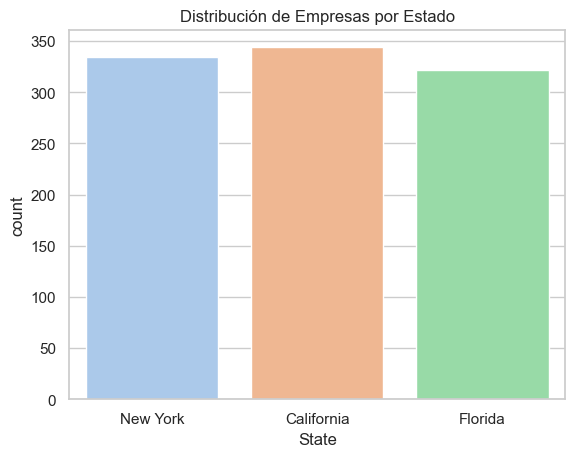

In [1298]:
df['State'].value_counts()
sns.countplot(data=df, x='State', hue='State')
plt.title('Distribución de Empresas por Estado')
plt.show()


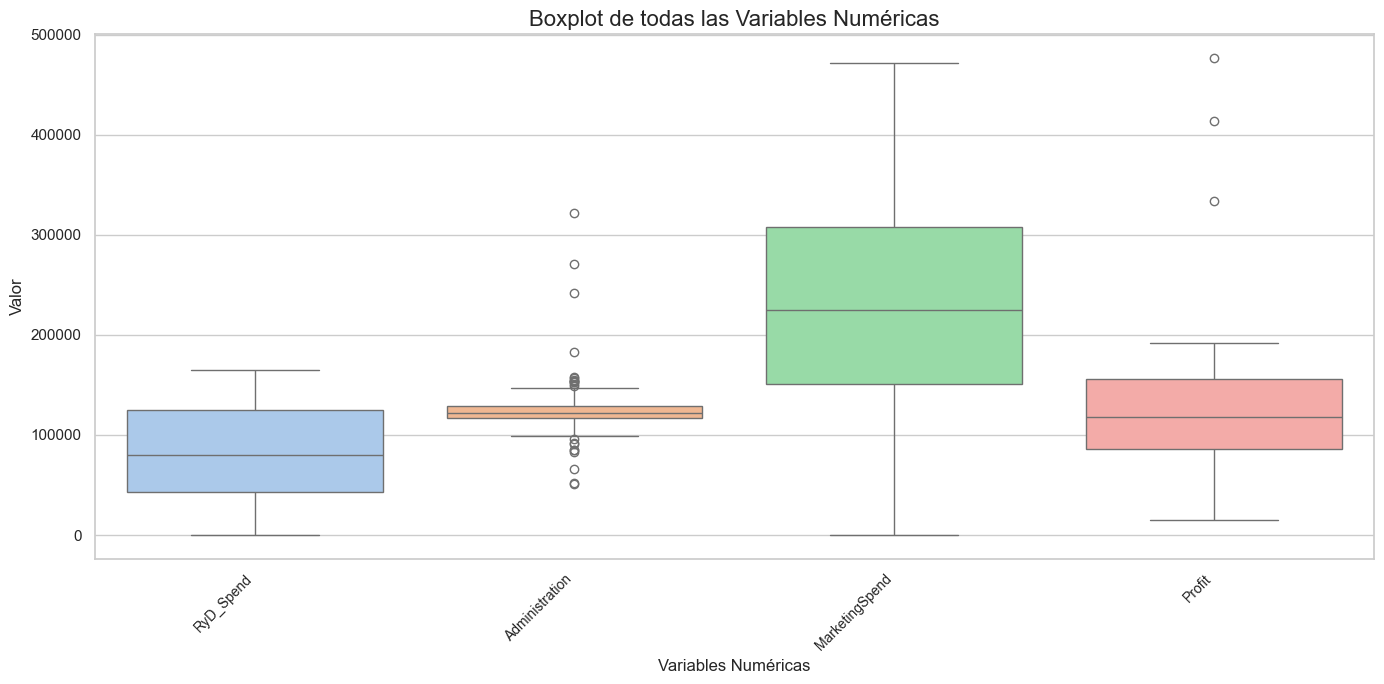

In [1299]:
numerical_cols = df.select_dtypes(include=np.number).columns
df_numerical = df[numerical_cols]


plt.figure(figsize=(14, 7)) # Ajusta el tamaño según la cantidad de columnas
sns.boxplot(data=df_numerical)
plt.title('Boxplot de todas las Variables Numéricas', fontsize=16)
plt.ylabel('Valor', fontsize=12)
plt.xlabel('Variables Numéricas', fontsize=12)

# Rotar las etiquetas del eje X si hay muchas columnas para evitar superposiciones
plt.xticks(rotation=45, ha='right', fontsize=10) # 'ha' es para la alineación horizontal
plt.tight_layout()
plt.show()

No aplicamos sobre profit ya que es la variable objetivo

In [1300]:
cols = ['Administration']
df_copy = df.copy()
winsor = Winsorizer(capping_method='iqr', tail='both',fold=1.5)
df_copy[cols] = winsor.fit_transform(df_copy[cols])

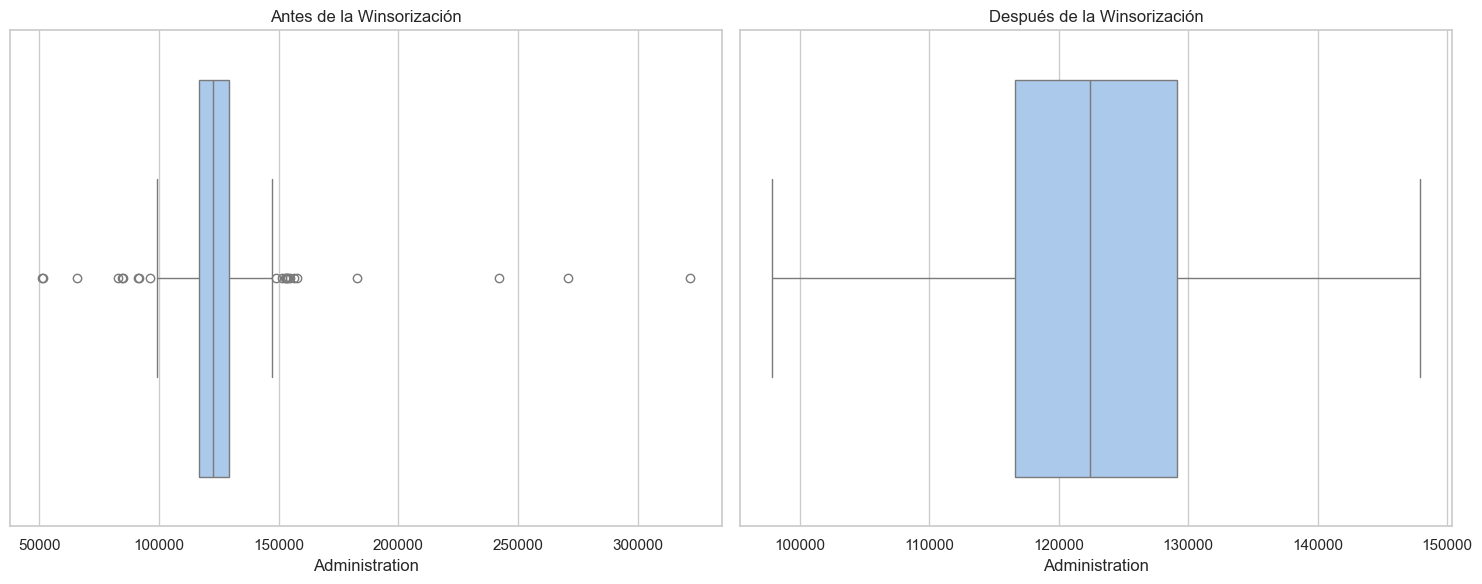

In [1301]:
# Crear una figura con dos subplots, uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Datos originales
sns.boxplot(data=df, x='Administration', ax=axes[0])
axes[0].set_title('Antes de la Winsorización')

# Gráfico 2: Datos limpios
sns.boxplot(data=df_copy, x='Administration', ax=axes[1])
axes[1].set_title('Después de la Winsorización')

plt.tight_layout()
plt.show()

In [1302]:
df_copy.describe()

,RyD_Spend,Administration,MarketingSpend,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,81668.927200,122667.046968,226205.058419,119546.164656
std,46537.567891,8027.234926,91578.393542,42888.633848
min,0.000000,97893.035125,0.000000,14681.400000
25%,43084.500000,116640.684850,150969.584600,85943.198543
50%,79936.000000,122421.612150,224517.887350,117641.466300
75%,124565.500000,129139.118000,308189.808525,155577.107425
max,165349.200000,147886.767725,471784.100000,476485.430000


como se correlacionan las variables?

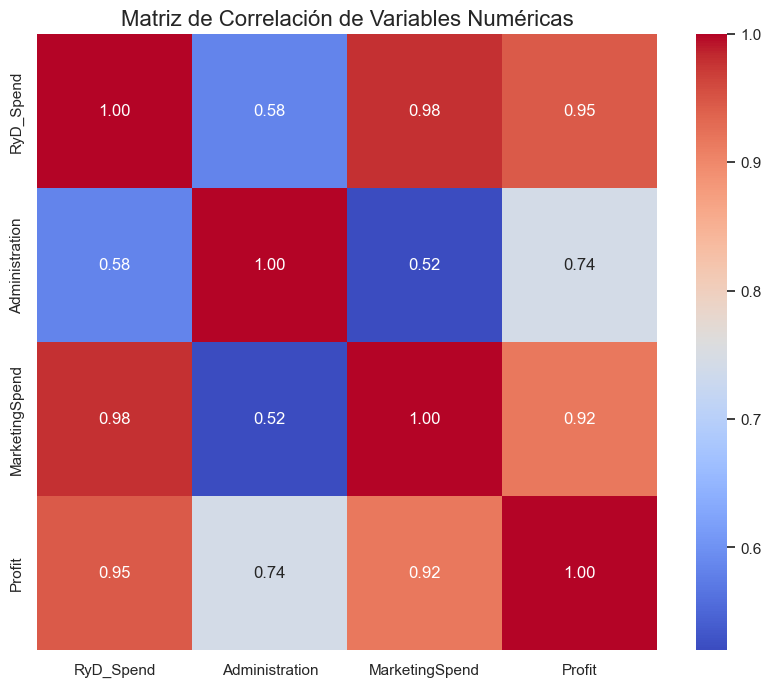

In [1303]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

In [1304]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RyD_Spend       1000 non-null   float64
 1   Administration  1000 non-null   float64
 2   MarketingSpend  1000 non-null   float64
 3   State           1000 non-null   object 
 4   Profit          1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


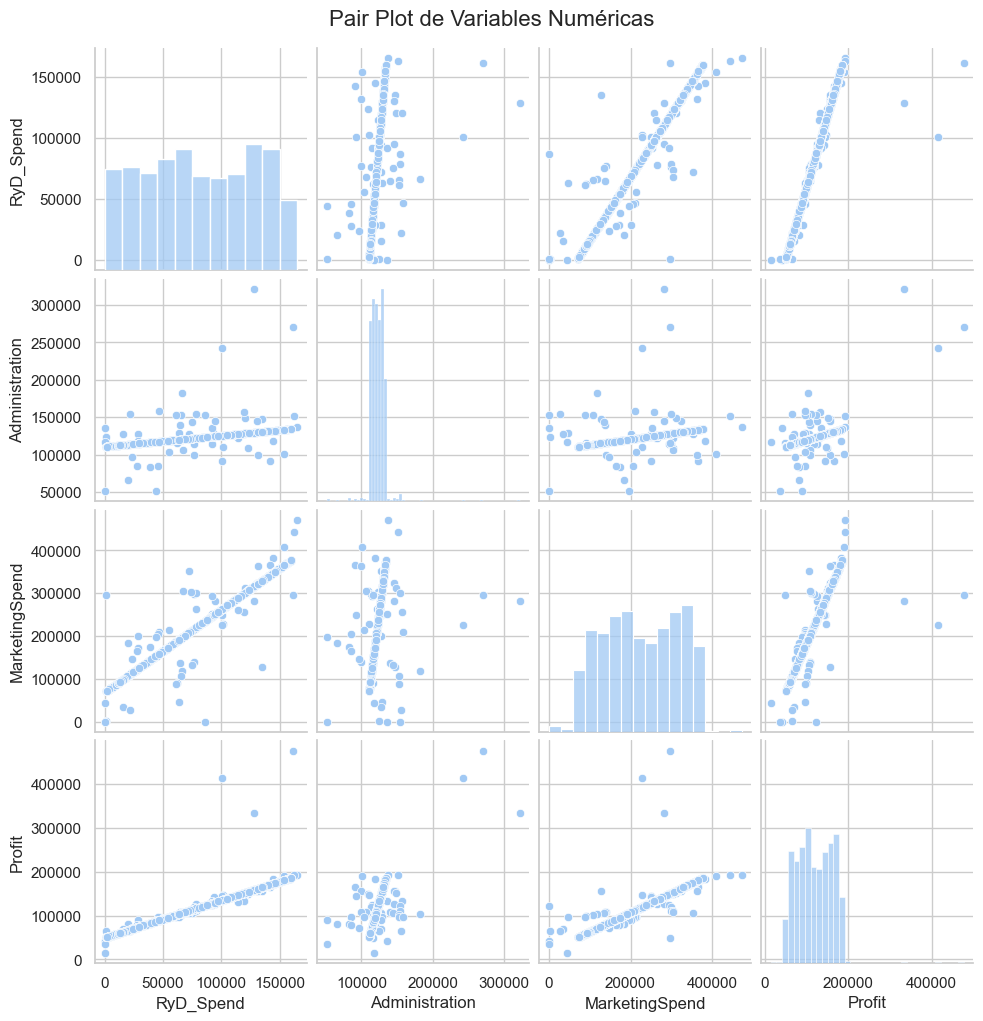

In [1305]:
sns.pairplot(df_numerical)
plt.suptitle('Pair Plot de Variables Numéricas', y=1.02, fontsize=16) # Ajusta el título
plt.show()

DROP FIRST SI O NO?

In [1306]:
enc = OneHotEncoder(sparse_output=False)
estados = enc.fit_transform(df_copy[['State']])
estados_df = pd.DataFrame(estados, columns=enc.get_feature_names_out(['State']), index=df_copy.index)
df_final = pd.concat([estados_df, df_copy], axis=1).drop(columns='State',axis=1)


In [1307]:
df_final.sample(5)

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend,Profit
130,0.0,1.0,0.0,94548.00,124420.3749,251209.6634,129804.43970
0,0.0,0.0,1.0,165349.20,136897.8000,471784.1000,192261.83000
25,1.0,0.0,0.0,64664.71,139553.1600,137962.6200,107404.34000
795,0.0,1.0,0.0,48789.00,117662.4774,162917.5479,90712.92084
658,1.0,0.0,0.0,138525.00,130915.0986,336063.4050,167373.61130


## SPLIT Companies

In [1308]:
X = df_final.drop(columns='Profit', axis=1)
y = df_final['Profit']

In [1309]:
# Obtengo datos de entrenamiento y de testeo
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2,
                            random_state=13, shuffle=True)

In [1310]:
X_train.head()

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend
133,0.0,1.0,0.0,102790.0,125637.5910,267112.62490
233,1.0,0.0,0.0,86530.0,123236.2402,235738.91050
643,0.0,0.0,1.0,4187.0,111075.4508,76857.86711
497,1.0,0.0,0.0,105465.0,126032.6472,272274.04470
281,1.0,0.0,0.0,70529.0,120873.1396,204864.93730


In [1311]:
col_scl = ['RyD_Spend','Administration', 'MarketingSpend']
esc = StandardScaler()
X_train[col_scl] = esc.fit_transform(X_train[col_scl])
X_test[col_scl] = esc.transform(X_test[col_scl])

In [1312]:
X_train.head()

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend
133,0.0,1.0,0.0,0.501721,0.389475,0.496556
233,1.0,0.0,0.0,0.149549,0.095252,0.152852
643,0.0,0.0,1.0,-1.633903,-1.394737,-1.587714
497,1.0,0.0,0.0,0.559659,0.437879,0.553100
281,1.0,0.0,0.0,-0.197014,-0.194285,-0.185377


In [1313]:
X_test.head()

,State_California,State_Florida,State_New York,RyD_Spend,Administration,MarketingSpend
945,0.0,0.0,1.0,-1.481901,-1.267747,-1.439367
452,0.0,0.0,1.0,1.026125,0.827589,1.008349
304,1.0,0.0,0.0,-1.113030,-0.959573,-1.079366
433,0.0,1.0,0.0,-0.793216,-0.692383,-0.767243
864,0.0,0.0,1.0,-1.148074,-0.988850,-1.113568


## Decision tree - Companies

Para determinar la configuración óptima del Árbol de Decisión de Regresión, se empleará la técnica de Búsqueda en Grilla con Validación Cruzada (GridSearchCV)

In [1314]:
dtr = DecisionTreeRegressor(random_state=42)

param_grid = {
    'criterion': ['squared_error'], # Opción principal para regresión
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [1315]:
grid_search = GridSearchCV(estimator=dtr, param_grid=param_grid, cv=5, 
                           scoring='neg_mean_squared_error', verbose=1, n_jobs=-1) # scoring con rmse para mas interpretabilidad perrriiii

# Entrenar en los datos de entrenamiento
grid_search.fit(X_train, y_train)

# --- Paso 3: Obtener el Mejor Modelo y Predecir ---
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
best_tree = grid_search.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred = best_tree.predict(X_test)
y_pred_train = best_tree.predict(X_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros encontrados: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


Las métricas del conjunto de train son prácticamente perfectas, lo cual puede mostrar algún indicio de overfitting. 

In [1316]:
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

print(f"\nResultados en el conjunto de Train:")
print(f"Error Absoluto Medio (MAE): {mae_train:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_train:.2f}")
print(f"R2: {r2_train}")



Resultados en el conjunto de Train:
Error Absoluto Medio (MAE): 1753.34
Raíz del Error Cuadrático Medio (RMSE): 12701.17
R2: 0.9142469342478746


Las métricas obtenidas en test son incluso mejores que las obtenidas en train(casi perfectas), por lo que se intuye que el modelo ha conseguido una gran capacidad de predicción de la variable profit en base a las variables explicativas del dataset.


Resultados en el conjunto de test:
Error Absoluto Medio (MAE): 1109.18
Raíz del Error Cuadrático Medio (RMSE): 3687.43
R2: 0.9915816233967283


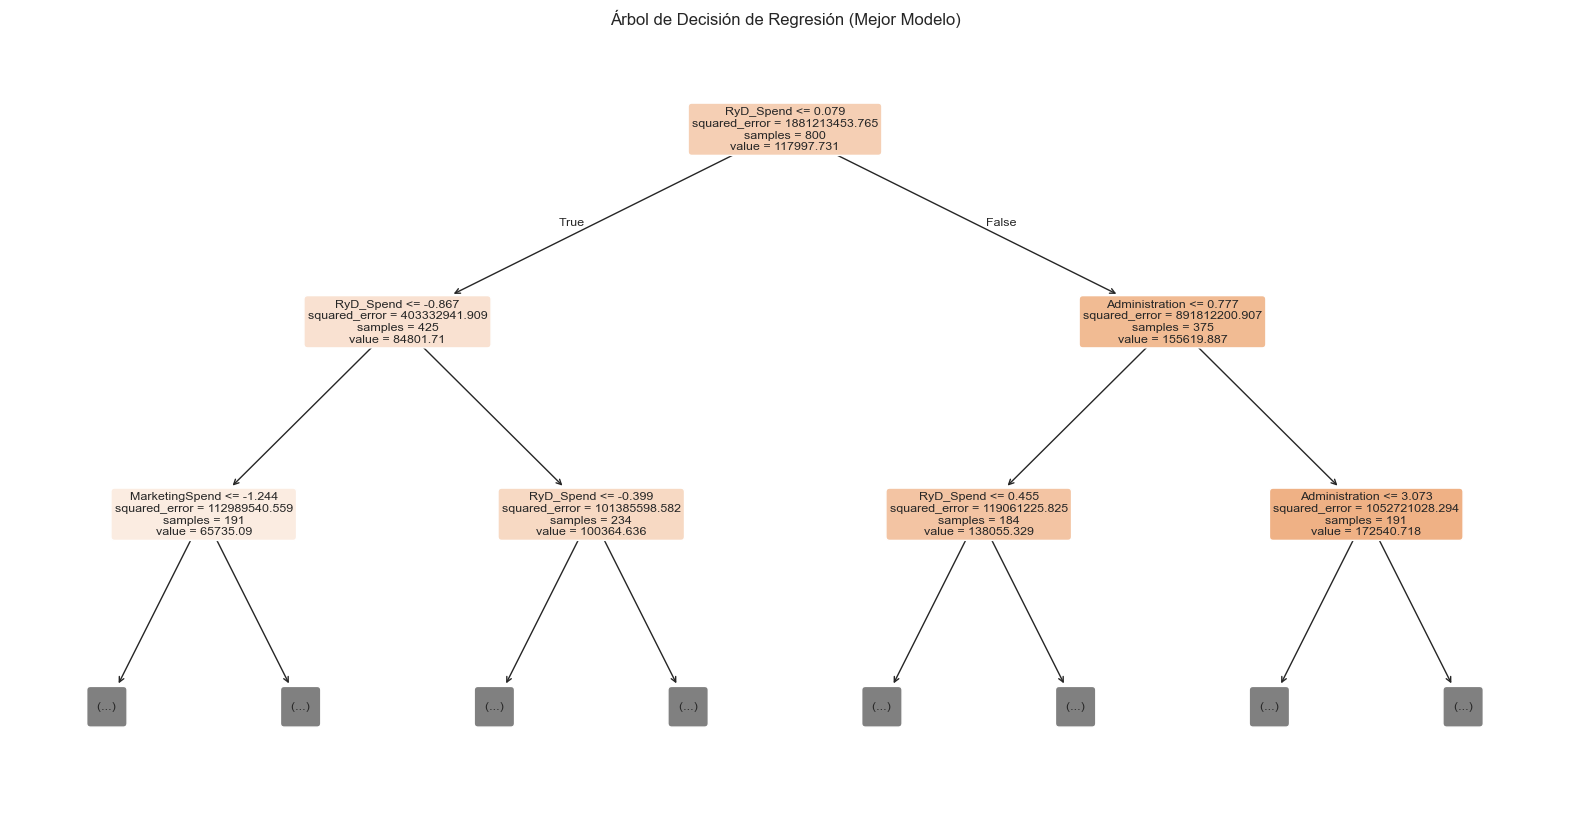

In [1317]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nResultados en el conjunto de test:")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"R2: {r2}")

# --- Paso 5: Graficar el Árbol ---
plt.figure(figsize=(20, 10))
plot_tree(best_tree, 
          feature_names=X_train.columns.tolist(), # Asegúrate que X_train sea un DataFrame
          filled=True, 
          rounded=True,
          max_depth=2) # Limitar la profundidad para que sea legible
plt.title("Árbol de Decisión de Regresión (Mejor Modelo)")
plt.show()

## EDA Drugs

In [1318]:
df2 = pd.read_csv('drugType.csv')

In [1319]:
df2.head()

,Edad,Sexo,BP,Colesterol,Na_a_K,Droga
0,23,F,Alto,Alto,25.355,DrogaY
1,47,M,Bajo,Alto,13.093,DrogaC
2,47,M,Bajo,Alto,10.114,DrogaC
3,28,F,Normal,Alto,7.798,DrogaX
4,61,F,Bajo,Alto,18.043,DrogaY


In [1320]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Edad        200 non-null    int64  
 1   Sexo        200 non-null    object 
 2   BP          200 non-null    object 
 3   Colesterol  200 non-null    object 
 4   Na_a_K      200 non-null    float64
 5   Droga       200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [1321]:
df2.describe()

,Edad,Na_a_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [1322]:
print(df2.isna().sum()[df2.isna().sum() > 0]) # no hay nulos

Series([], dtype: int64)


In [1323]:
df2_copy = df2.copy()

In [1324]:
# Convertimos a categoria la columna objetivo
df2_copy['Droga'] = df2_copy['Droga'].astype('category')
df2_copy["Droga"].value_counts()

Droga
DrogaY    91
DrogaX    54
DrogaA    23
DrogaC    16
DrogaB    16
Name: count, dtype: int64

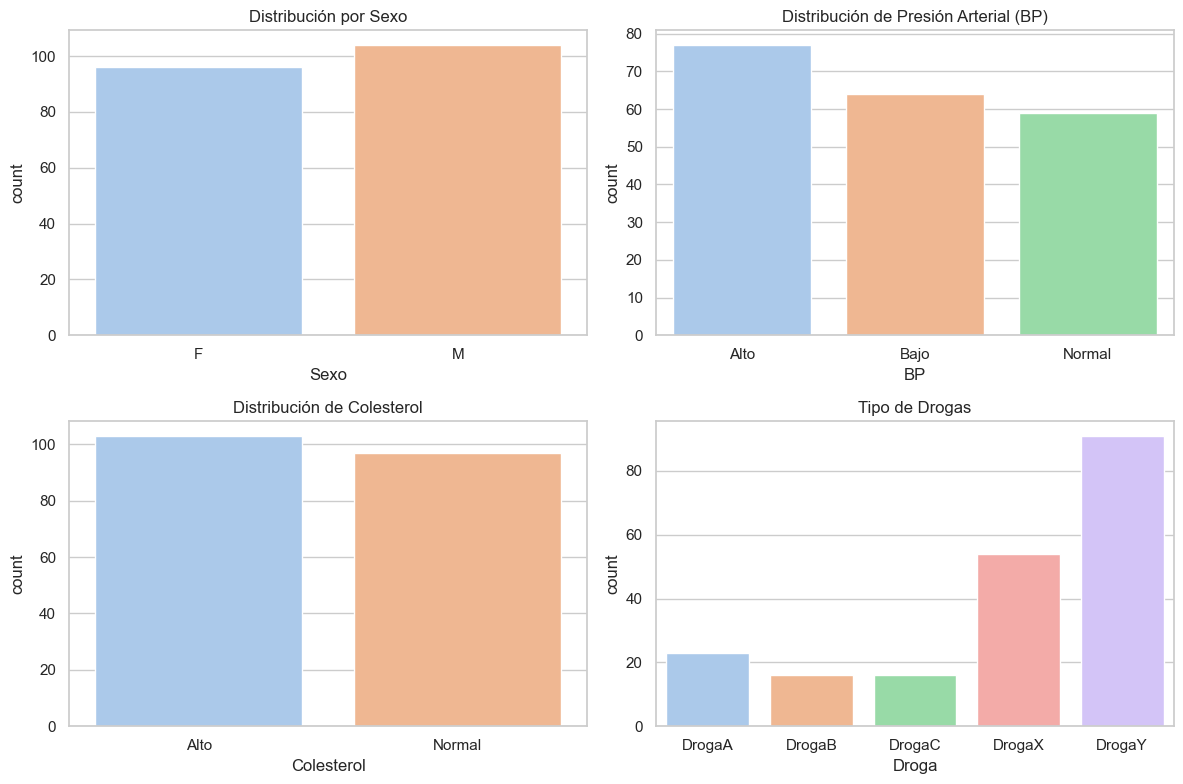

In [1325]:
sns.set(style="whitegrid", palette="pastel")

# Crear figura y ejes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Gráficos
sns.countplot(data=df2_copy, x='Sexo', hue='Sexo', ax=axes[0,0])
axes[0,0].set_title('Distribución por Sexo')

sns.countplot(data=df2_copy, x='BP', hue='BP', ax=axes[0,1])
axes[0,1].set_title('Distribución de Presión Arterial (BP)')

sns.countplot(data=df2_copy, x='Colesterol', hue='Colesterol', ax=axes[1,0])
axes[1,0].set_title('Distribución de Colesterol')

sns.countplot(data=df2_copy, x='Droga', hue='Droga', ax=axes[1,1])
axes[1,1].set_title('Tipo de Drogas')

# Ajustar espaciado
plt.tight_layout()
plt.show()


Se puede observar un desbalance de la cantidad de entradas disponibles para cada tipo de droga, habiendo menos de 20 entradas para el tipo B y el tipo C. 

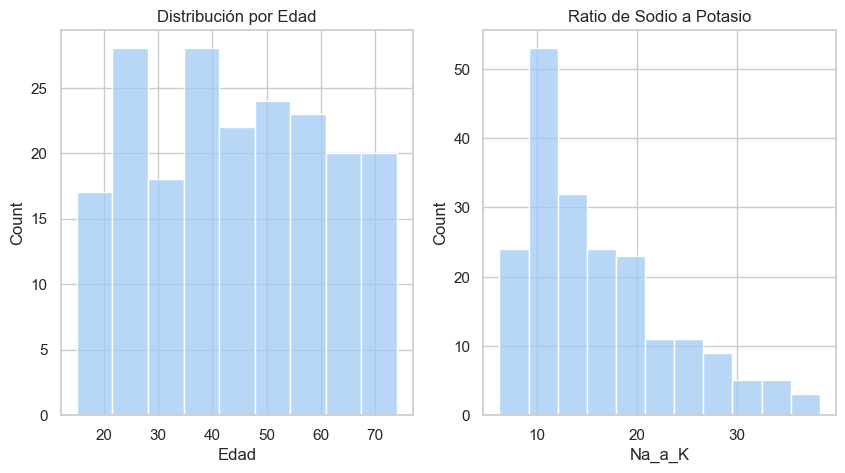

In [1326]:
sns.set(style="whitegrid", palette="pastel")

# Crear figura y ejes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Gráficos
sns.histplot(data=df2_copy, x='Edad', ax=axes[0])
axes[0].set_title('Distribución por Edad')

sns.histplot(data=df2_copy, x='Na_a_K', ax=axes[1])
axes[1].set_title('Ratio de Sodio a Potasio')

# Ajustar espaciado
#plt.tight_layout()
plt.show()


Se ve ligeramente sesgado a la derecha El ratio de sodio y potacio

CODIFICACION DE VARIABLES CATEGORICAS **ORDINALES**
ESTA BIEN ESTE ENCODING?

In [1327]:
df2_copy.BP.unique()

array(['Alto', 'Bajo', 'Normal'], dtype=object)

In [1328]:
# Codificamos de esta manera ya que es una varable categorica ordinal, el orden de bajo normal y alto importa
bp_map = {'Bajo': 0, 'Normal': 1, 'Alto': 2}
df2_copy['BP'] = df2_copy['BP'].map(bp_map)

In [1329]:
df2_copy.Colesterol.unique()

array(['Alto', 'Normal'], dtype=object)

In [1330]:
col_map = {'Normal': 0, 'Alto': 1}
df2_copy['Colesterol'] = df2_copy['Colesterol'].map(col_map)

In [1331]:
df2_copy.head()

,Edad,Sexo,BP,Colesterol,Na_a_K,Droga
0,23,F,2,1,25.355,DrogaY
1,47,M,0,1,13.093,DrogaC
2,47,M,0,1,10.114,DrogaC
3,28,F,1,1,7.798,DrogaX
4,61,F,0,1,18.043,DrogaY


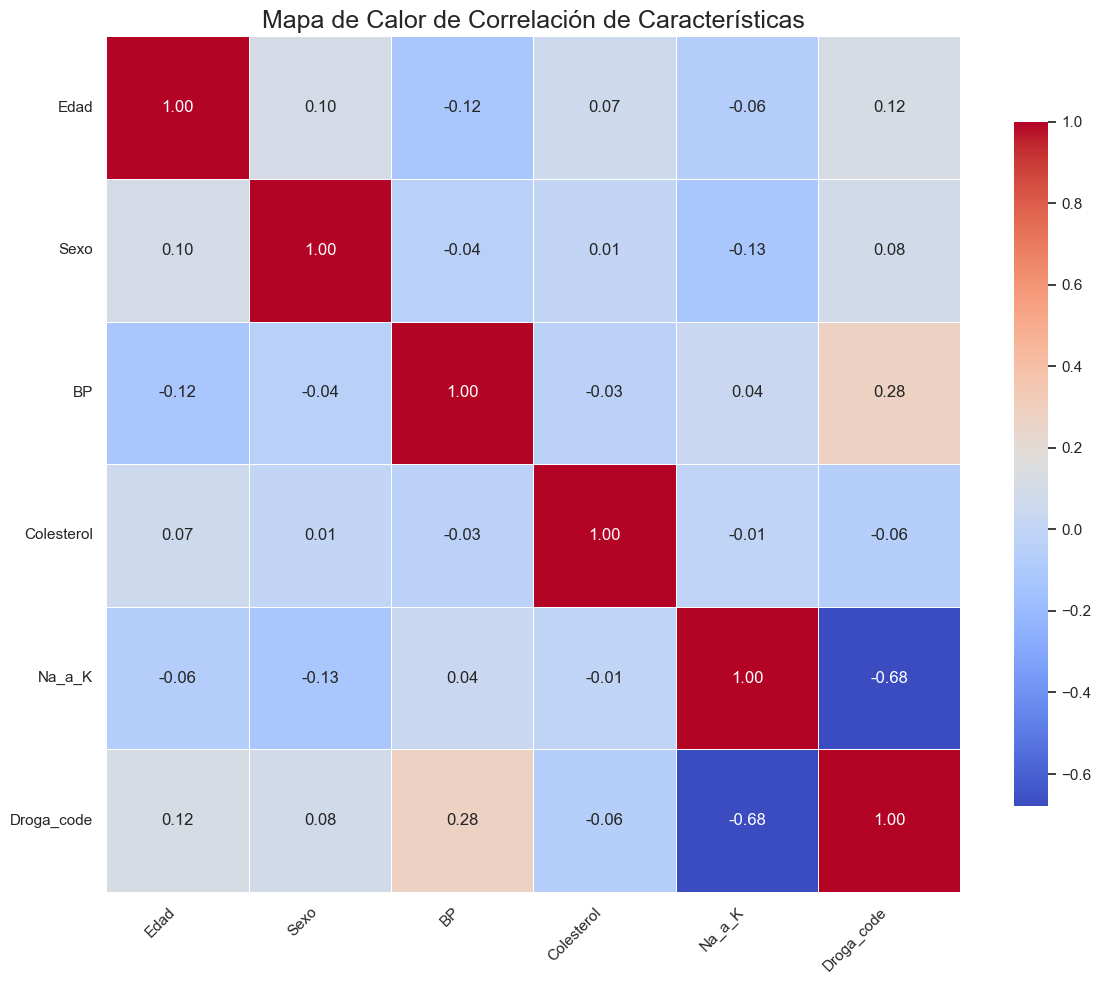

In [1332]:
# Creamos copia
df_corr = df2_copy.copy()
df_corr['Droga_code'] = pd.factorize(df_corr['Droga'])[0]
df_corr['Sexo'] = df_corr['Sexo'].apply(lambda x: 1 if x == 'M' else 0)
corr_matrix = df_corr[['Edad', 'Sexo', 'BP', 'Colesterol', 'Na_a_K', 'Droga_code']].corr()


plt.figure(figsize=(12, 10))  # Tamaño generoso para que se vea bien


sns.heatmap(
    corr_matrix,       
    annot=True,           
    fmt=".2f",            
    cmap='coolwarm',      
    linewidths=.5,        
    cbar_kws={"shrink": .8} 
)

plt.title('Mapa de Calor de Correlación de Características', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)


plt.tight_layout() # Ajusta el gráfico para que todo encaje bien
plt.show()

para la columna Sexo se plantea el uso de OneHotEncoding 

In [1333]:
enc = OneHotEncoder(sparse_output=False) # como no es regresion no usamos drop first


fit = enc.fit_transform(df2_copy[['Sexo']])

df_enc = pd.DataFrame(fit, columns=enc.get_feature_names_out(['Sexo']), index=df2.index)

# concatenamos los dataframe y dropeamos la columna que codificamos
df2_copy = pd.concat([df2_copy, df_enc], axis=1)
df2_copy.drop('Sexo', axis=1, inplace=True)

In [1334]:
df2_copy.head()

,Edad,BP,Colesterol,Na_a_K,Droga,Sexo_F,Sexo_M
0,23,2,1,25.355,DrogaY,1.0,0.0
1,47,0,1,13.093,DrogaC,0.0,1.0
2,47,0,1,10.114,DrogaC,0.0,1.0
3,28,1,1,7.798,DrogaX,1.0,0.0
4,61,0,1,18.043,DrogaY,1.0,0.0


## SPLIT Drug

In [1335]:
X = df2_copy.drop('Droga', axis=1)
y = df2_copy['Droga']

# --- Escenario 1: División 80/20 ---
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# --- Escenario 2: División 70/30 ---
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [1336]:
X_train_80.head()

,Edad,BP,Colesterol,Na_a_K,Sexo_F,Sexo_M
196,16,0,1,12.006,0.0,1.0
134,42,2,1,21.036,1.0,0.0
24,33,0,1,33.486,1.0,0.0
2,47,0,1,10.114,0.0,1.0
97,56,2,1,25.395,1.0,0.0


In [1337]:
X_test_20.head()

,Edad,BP,Colesterol,Na_a_K,Sexo_F,Sexo_M
84,47,0,1,10.067,1.0,0.0
32,49,0,0,11.014,0.0,1.0
110,50,2,1,7.490,0.0,1.0
129,32,1,1,7.477,1.0,0.0
57,40,2,1,27.826,0.0,1.0


In [1338]:
X_train_80.columns

Index(['Edad', 'BP', 'Colesterol', 'Na_a_K', 'Sexo_F', 'Sexo_M'], dtype='object')

ES NECESARIO ESCALAR? 


ESTA BIEN ESCALAR SOLO ESAS DOS COLUMNAS? 

In [1339]:
columnas = ['Edad','Na_a_K','Colesterol','BP']
esc = StandardScaler()

# escalamos los split de 70-30 y 80-20
X_train_80[columnas] = esc.fit_transform(X_train_80[columnas])
X_test_20[columnas] = esc.transform(X_test_20[columnas])

X_train_70[columnas] = esc.fit_transform(X_train_70[columnas])
X_test_30[columnas] = esc.transform(X_test_30[columnas])

ESTA BIEN EL LABEL ENCODER PARRA LA Y O NO HACE FALTA

In [1340]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_70)
y_test_encoded = le.transform(y_test_30)

In [1341]:
nombres_drogas = le.classes_

## Modelo 70-30

In [1342]:
X_train_70.head()

,Edad,BP,Colesterol,Na_a_K,Sexo_F,Sexo_M
158,0.805604,-1.279672,0.985815,-0.810058,1.0,0.0
46,-0.514918,1.141329,0.985815,-0.433269,1.0,0.0
130,1.465865,-0.069171,0.985815,0.619803,1.0,0.0
31,1.705960,1.141329,0.985815,-0.934895,0.0,1.0
85,0.805604,1.141329,0.985815,-0.313130,0.0,1.0


In [1343]:
X_train_70.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 158 to 175
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Edad        140 non-null    float64
 1   BP          140 non-null    float64
 2   Colesterol  140 non-null    float64
 3   Na_a_K      140 non-null    float64
 4   Sexo_F      140 non-null    float64
 5   Sexo_M      140 non-null    float64
dtypes: float64(6)
memory usage: 7.7 KB


In [1344]:
dtr_70 = DecisionTreeClassifier(random_state=42)

param_grid_70 = {
    'criterion': ['gini', 'entropy'], # Opción principal para regresión
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [3, 5, 7, 9, 11, 13],
    'min_samples_leaf': [1, 2, 4,8,12]
}

In [1345]:
grid_search = GridSearchCV(estimator=dtr_70, param_grid=param_grid_70, cv=5, 
                           scoring='f1_weighted', verbose=1, n_jobs=-1) 

# Entrenar en los datos de entrenamiento
grid_search.fit(X_train_70, y_train_encoded)

# --- Paso 3: Obtener el Mejor Modelo y Predecir ---
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
best_tree = grid_search.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred_30_test = best_tree.predict(X_test_30)
y_pred_70_train = best_tree.predict(X_train_70)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Mejores parámetros encontrados: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3}


In [1346]:
# Generar matrices de confusión.
confusion_70_train = confusion_matrix(y_train_encoded,y_pred_70_train)
confusion_30_test = confusion_matrix(y_test_encoded,y_pred_30_test)

Se observan métricas perfectas para train, lo cual es un gran indicio de posible overfitting.

In [1347]:
# Métricas para Train
print(classification_report(y_train_encoded,y_pred_70_train,target_names=nombres_drogas))

              precision    recall  f1-score   support

      DrogaA       1.00      1.00      1.00        16
      DrogaB       1.00      1.00      1.00        11
      DrogaC       1.00      1.00      1.00        11
      DrogaX       1.00      1.00      1.00        38
      DrogaY       1.00      1.00      1.00        64

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



Como se ve debajo, la matriz obtenida es la perfecta, con valores solo en la diagonal.

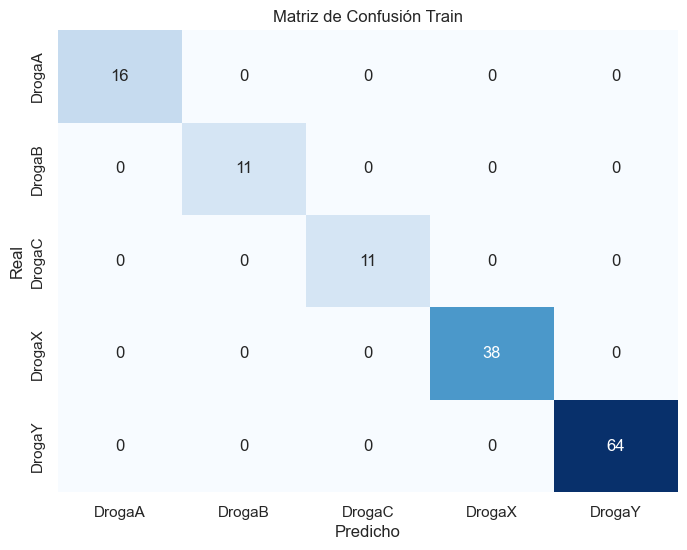

In [1348]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_70_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Train')
plt.show()

Las métricas siguen siendo extremadamente positivas en test, por lo que se concluye que se ha llegado a obtener un modelo muy preciso a la hora de predecir las diferentes drogas en base a datos del paciente.

In [1349]:
# Métricas para test
print(classification_report(y_test_encoded,y_pred_30_test,target_names=nombres_drogas))

              precision    recall  f1-score   support

      DrogaA       0.88      1.00      0.93         7
      DrogaB       1.00      0.80      0.89         5
      DrogaC       1.00      1.00      1.00         5
      DrogaX       1.00      1.00      1.00        16
      DrogaY       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



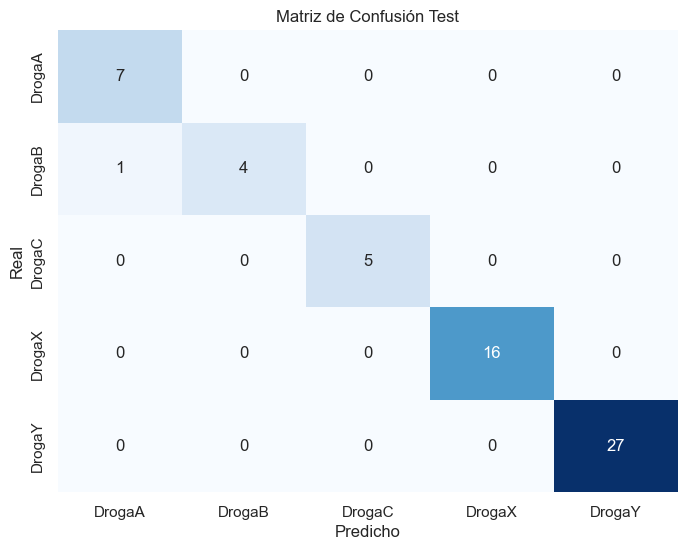

In [1350]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_30_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=le.classes_,  
    yticklabels=le.classes_   
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Test')
plt.show()

Se visualiza a continuación el árbol obtenido durante el entrenamiento.

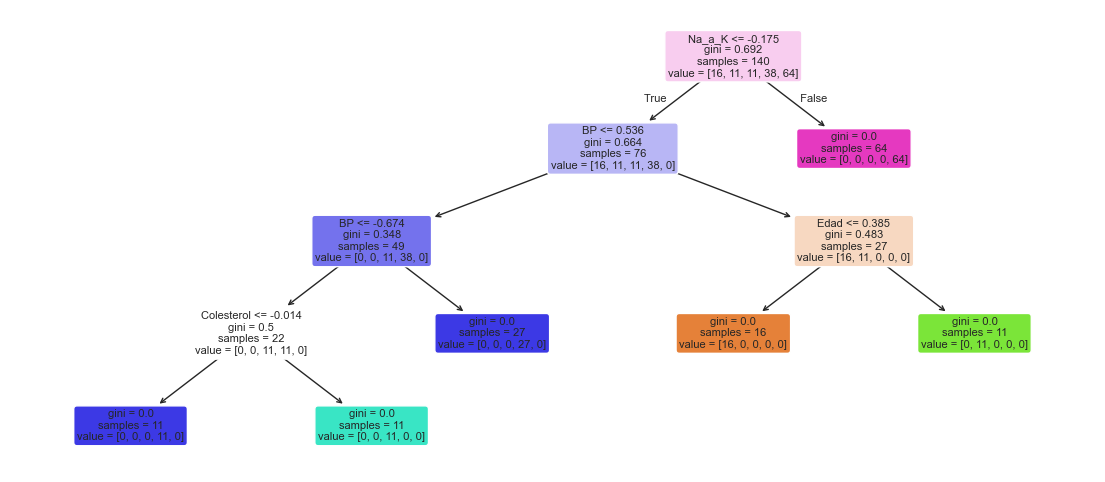

In [1351]:
plt.figure(figsize=(14,6))
plot_tree(grid_search.best_estimator_, feature_names=X_train_70.columns, fontsize=8, filled=True,
               rounded=True)
plt.show()

## Modelo 80-20

# Bayes Ingenuo

In [1352]:
df2.columns

Index(['Edad', 'Sexo', 'BP', 'Colesterol', 'Na_a_K', 'Droga'], dtype='object')

In [1353]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Edad        200 non-null    int64  
 1   Sexo        200 non-null    object 
 2   BP          200 non-null    object 
 3   Colesterol  200 non-null    object 
 4   Na_a_K      200 non-null    float64
 5   Droga       200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [1354]:
df2.describe()

,Edad,Na_a_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [1355]:
df2.sample(5)

,Edad,Sexo,BP,Colesterol,Na_a_K,Droga
192,72,M,Bajo,Alto,16.310,DrogaY
66,29,M,Alto,Alto,12.856,DrogaA
199,40,F,Bajo,Normal,11.349,DrogaX
176,48,M,Alto,Normal,10.446,DrogaA
167,57,F,Normal,Alto,14.216,DrogaX


In [1356]:
df3 = df2.copy()

Discretización de variables para Naive Bayes

In [1357]:
df3['Na_a_K_Cat'] = pd.qcut(df3['Na_a_K'], q=4, labels=False)
df3['Edad_Cat'] = pd.qcut(df3['Edad'], q=4, labels = False)
df3 = df3.drop(columns=["Edad","Na_a_K"])

In [1358]:
df3['Sexo'] = df3['Sexo'].apply(lambda x: 1 if x == 'M' else 0)
bp_map = {'Bajo': 0, 'Normal': 1, 'Alto': 2}
df3['BP'] = df3['BP'].map(bp_map)
col_map = {'Normal': 0, 'Alto': 1}
df3['Colesterol'] = df3['Colesterol'].map(col_map)

PREGUNTAR SI HACE FALTA OHE PARA NA_A_K, AFECTAN NEGATIVAMENTE LA suposicion 

In [1359]:
df3.head()

,Sexo,BP,Colesterol,Droga,Na_a_K_Cat,Edad_Cat
0,0,2,1,DrogaY,3,0
1,1,0,1,DrogaC,1,2
2,1,0,1,DrogaC,0,2
3,0,1,1,DrogaX,0,0
4,0,0,1,DrogaY,2,3


In [1360]:
X2 = df3.drop('Droga', axis=1)
y2 = df3['Droga']

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2)

ESTA BIEN ESTE ENCODING? 

In [1361]:
# le_n = LabelEncoder()
# y_train_encoded_n = le.fit_transform(y_train_n)
# y_test_encoded_n = le.transform(y_test_n)

In [1362]:
le_na = LabelEncoder()
X_train_n["Na_a_K_Cat"] = le_na.fit_transform(X_train_n["Na_a_K_Cat"])
X_test_n["Na_a_K_Cat"] = le_na.transform(X_test_n["Na_a_K_Cat"])

In [1363]:
X_train_n

,Sexo,BP,Colesterol,Na_a_K_Cat,Edad_Cat
158,0,0,1,0,3
46,0,2,1,1,1
130,0,1,1,3,3
31,1,2,1,0,3
85,1,2,1,1,3
...,...,...,...,...,...
77,0,2,0,2,0
185,0,1,0,3,2
120,1,1,1,3,0
177,1,1,1,2,0


In [1364]:
# y_train_encoded_n

ESTA BIEN USAR MULTINOMIAL? 
UNA VEZ QUE SE LLEVARON TODAS LAS VARIABLES A RANGOS DISCRETOS

In [1365]:
clf_MNB = MultinomialNB()
clf_MNB.fit(X_train_n, y_train_n)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [1366]:
pred_MNB_train= clf_MNB.predict(X_train_n)
pred_MNB_test= clf_MNB.predict(X_test_n)

SE OBTIENE UNA PRECISION Y UN RECALL DE 0 EN B Y C, LAS MISMAS SON LAS DOS CLASES MINORITARIAS EN EL DATASET; PUEDO ARREGLARLO DE ALGUNA MANERA? O EL RESULTADO SERÁ ESE? 

In [1367]:
print(classification_report(y_train_n,pred_MNB_train,target_names = nombres_drogas));

              precision    recall  f1-score   support

      DrogaA       1.00      0.12      0.22        16
      DrogaB       0.00      0.00      0.00        11
      DrogaC       0.00      0.00      0.00        11
      DrogaX       0.48      0.53      0.50        38
      DrogaY       0.67      1.00      0.80        64

    accuracy                           0.61       140
   macro avg       0.43      0.33      0.30       140
weighted avg       0.55      0.61      0.53       140



d:\Facultad\CUATRI 4\Data Mining\TP2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Facultad\CUATRI 4\Data Mining\TP2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Facultad\CUATRI 4\Data Mining\TP2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [1368]:
print(classification_report(y_test_n,pred_MNB_test,target_names = nombres_drogas));

              precision    recall  f1-score   support

      DrogaA       1.00      0.14      0.25         7
      DrogaB       0.00      0.00      0.00         5
      DrogaC       0.00      0.00      0.00         5
      DrogaX       0.42      0.50      0.46        16
      DrogaY       0.65      0.96      0.78        27

    accuracy                           0.58        60
   macro avg       0.41      0.32      0.30        60
weighted avg       0.52      0.58      0.50        60



d:\Facultad\CUATRI 4\Data Mining\TP2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Facultad\CUATRI 4\Data Mining\TP2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Facultad\CUATRI 4\Data Mining\TP2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

# KNN

In [1369]:
df2_copy

,Edad,BP,Colesterol,Na_a_K,Droga,Sexo_F,Sexo_M
0,23,2,1,25.355,DrogaY,1.0,0.0
1,47,0,1,13.093,DrogaC,0.0,1.0
2,47,0,1,10.114,DrogaC,0.0,1.0
3,28,1,1,7.798,DrogaX,1.0,0.0
4,61,0,1,18.043,DrogaY,1.0,0.0
...,...,...,...,...,...,...,...
195,56,0,1,11.567,DrogaC,1.0,0.0
196,16,0,1,12.006,DrogaC,0.0,1.0
197,52,1,1,9.894,DrogaX,0.0,1.0
198,23,1,0,14.020,DrogaX,0.0,1.0


In [1370]:
X3 = df2_copy.drop('Droga', axis=1)
y3 = df2_copy['Droga']

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X3, y3, test_size=0.3, random_state=42, stratify=y3)

In [1371]:
scaler = StandardScaler()
X_train_k_scaled = scaler.fit_transform(X_train_k)
X_test_k_scaled = scaler.transform(X_test_k)

In [1372]:
knn = KNeighborsClassifier()

HACE FALTA CAMBIAR WEIGHTS EN LOS PARAMTROS? 

POR QUE ME DA SIEMPRWE QUE LA MEJOR CANTIDAD DE VECINOS ES UNO?
LAS METRICAS DE TEST Y DE TRAIN SON BUENAS IGUAL, EN DONDE ESTA EL ERROR ENTONCES?

In [1373]:
# Definir los parámetros a ajustar
parametros_grid = {'n_neighbors':  range(1, 30),
                   'p':[1,2],
                   }

# Inicializar el objeto GridSearchCV
grid_search = GridSearchCV(estimator = knn,
                           param_grid = parametros_grid,
                           cv=5,
                           scoring='f1_weighted')

In [1374]:
grid_search.fit(X_train_k_scaled, y_train_k)
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

Mejores parámetros encontrados: {'n_neighbors': 1, 'p': 1}


In [1375]:
best_knn = grid_search.best_estimator_

In [1376]:
y_pred_train_k = best_knn.predict(X_train_k_scaled)
y_pred_test_k = best_knn.predict(X_test_k_scaled)

In [1377]:
confusion_k_train = confusion_matrix(y_train_k,y_pred_train_k)
confusion_k_test = confusion_matrix(y_test_k,y_pred_test_k)

In [1378]:
print(classification_report(
    y_train_k, 
    y_pred_train_k, 
    target_names=nombres_drogas
))

              precision    recall  f1-score   support

      DrogaA       1.00      1.00      1.00        16
      DrogaB       1.00      1.00      1.00        11
      DrogaC       1.00      1.00      1.00        11
      DrogaX       1.00      1.00      1.00        38
      DrogaY       1.00      1.00      1.00        64

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



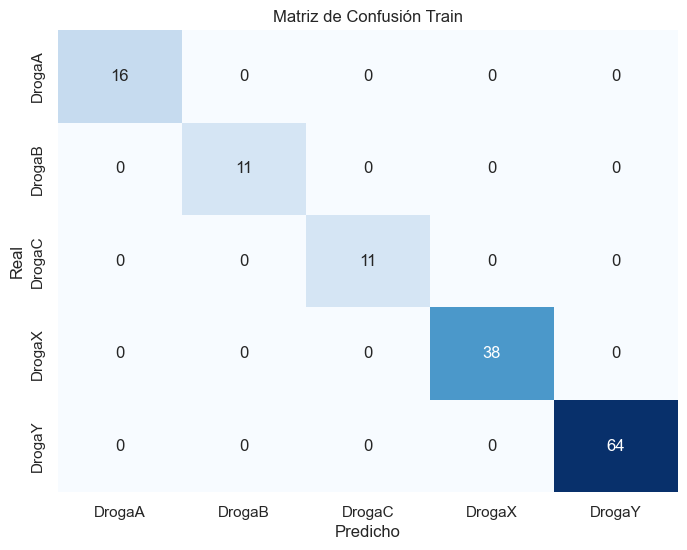

In [1379]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_k_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Train')
plt.show()

In [1380]:
print(classification_report(
    y_test_k, 
    y_pred_test_k, 
    target_names=nombres_drogas
))

              precision    recall  f1-score   support

      DrogaA       0.58      1.00      0.74         7
      DrogaB       0.75      0.60      0.67         5
      DrogaC       0.71      1.00      0.83         5
      DrogaX       0.94      0.94      0.94        16
      DrogaY       0.95      0.74      0.83        27

    accuracy                           0.83        60
   macro avg       0.79      0.86      0.80        60
weighted avg       0.87      0.83      0.84        60



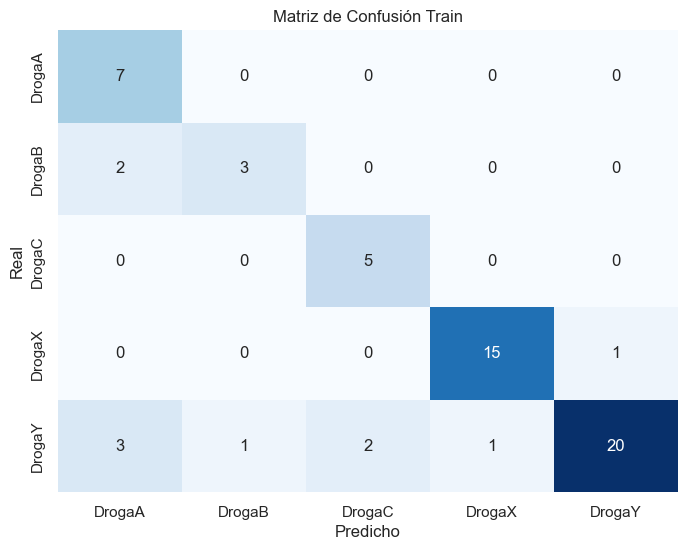

In [1381]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_k_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Train')
plt.show()